# SR Tutorial

2026 IAIFI Summer School

Tutorial lead: Jose M Munoz Arias

Professor: Miles Cranmer

# Solving Schrödinger's Equation by Search


In [1]:
# Uncomment on Colab.
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pysr", "sympy>=1.14"], check=True)

In [1]:
import os
os.environ.setdefault("PYTHON_JULIACALL_THREADS", "auto")
os.environ.setdefault("PYTHON_JULIACALL_AUTOLOAD_IPYTHON_EXTENSION", "no")

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pysr
from pysr import PySRRegressor, TemplateExpressionSpec

import session3_data as s3
from session3_data import *

REPRO = dict(deterministic=True, parallelism="serial", verbosity=0, progress=False)

## Introducing the problem

A bit of intro to the physics behind the problem. Or a bit of a refresher.

A quantum particle is described by a function $\psi(x)$, and everything measurable about the
particle is read off from that function. The one reading we will use is that $|\psi(x)|^2$ is the
probability density for finding the particle at $x$. 

We are going to be looking at the equation:

$$\hat H \psi = E\,\psi,$$

where $\hat H$ is the Hamiltonian operator, which is the sum of kinetic and potential energy:

$$\hat H \psi = -\tfrac12 \psi''(x) + V(x)\,\psi(x),$$

in natural units where $\hbar = m = c = 1$.

The first term is the kinetic energy, and the reason it involves a second derivative is
that curvature of $\psi$ is what momentum looks like in this language, so a state that wiggles
fast is a state that is moving fast.

We can just think of $\hat H$ as a matrix, and $\psi$ as a vector, and the equation is an eigenvalue problem:

$$-\tfrac12 \psi''(x) + V(x)\,\psi(x) = E\,\psi(x),$$

And most of... what we deal with in Nuclear Theory (and actually in many fields of physics) is solving this equation for a given $V(x)$ and arbitrarily complicated $\psi(x)$. 

---

## A VERY naive approach

The idea we would like to illustrate is how powerful is it to be able to encode custom operators in the search... so we can just try to solve the equation:

$$-\tfrac12 \psi''(x) + V(x)\,\psi(x) - E\,\psi(x) = 0.$$

There is a quote I really like... 
"Physics is the art of solving the harmonic oscillator..." 
Lets start with a simple harmonic oscillator, where $V(x) = \tfrac12 x^2$. 

findfont: Failed to find font weight medium, now using 400.


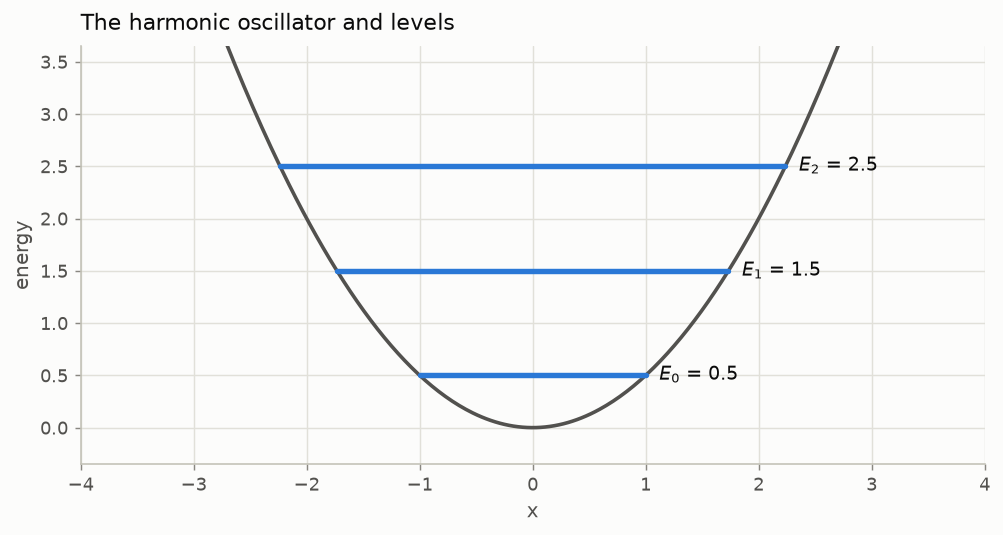

In [2]:
s3.plot_potential()

#### Something to consider first

Take a simpler equation first, $f'(x) = f(x)$, whose solution is $e^x$. The natural move is to
build the residual $f'(x) - f(x)$ and ask for it to be zero everywhere.

`D(f, 1)` is the derivative of component `f` with respect to its first argument, and inside the
combine string it is an ordinary Julia value, so it can be composed and differentiated again.
Fitting against a column of zeros with `elementwise_loss="(p, t) -> p^2"` makes the template's own
output the thing being minimised.

In [3]:
x_demo = np.linspace(0.0, 1.0, 60).reshape(-1, 1)

naive = TemplateExpressionSpec(
    expressions=["f"], variable_names=["x"],
    combine="df = D(f, 1); df(x) - f(x)")

collapse = PySRRegressor(
    expression_spec=naive, binary_operators=["+", "-", "*"], unary_operators=["exp"],
    elementwise_loss="(p, t) -> p^2", niterations=10, maxsize=8,
    random_state=0, **REPRO)
collapse.fit(x_demo, np.zeros(len(x_demo)), variable_names=["x"])
collapse.equations_[["complexity", "loss", "equation"]]

,complexity,loss,equation
0,1,0.0,f = 0.0


So we need to find a way to make the trivial solution unavailable to the search.

#### 'Divide and conquer'... literally

The trick is to divide through by $\psi$. Define the local energy

$$E_\text{loc}(x) = \frac{-\tfrac12\psi''(x) + V(x)\,\psi(x)}{\psi(x)},$$

which is constant, and equal to $E$, exactly when $\psi$ solves the equation at that $E$, and
which varies with $x$ for anything else. So we ask for $E_\text{loc}(x) - E$ to vanish, with $E$
a fitted parameter.

That does two useful things at once. It kills the trivial solution, since dividing by zero gives a
non-finite residual and PySR discards it. And it makes the whole thing
invariant under $\psi \to c\psi$, which is exactly right, because normalisation is not something
the equation determines.

This techique is very common in the Variational Monte Carlo literature.

To solve the problem, let me define a grid $X$ of points in $x$ and the potential $V(x)$ at those points.

The grid carries three ordinary columns: the position, the potential there, and a third column
`w` we will not use until the end.

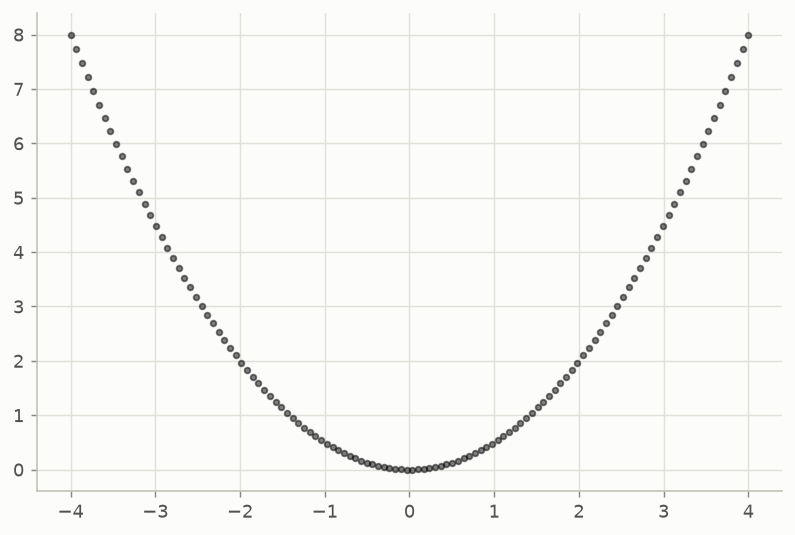

In [7]:
X, y = collocation(harmonic, lo=-4.0, hi=4.0, n=120) # this is using y=0 across all x values

# Plot the collocation points and the potential
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], s=10, color="black", alpha=0.5)

In [8]:
LOCAL = ("d1 = D(f, 1); d2 = D(d1, 1); fx = f(x); "
         "(-0.5f0*d2(x) + (V - E[1])*fx) / fx")

SEARCH_1D = dict(binary_operators=["+", "-", "*"], unary_operators=["exp"],
                 elementwise_loss="(p, t) -> p^2", niterations=20, maxsize=14,
                 **REPRO)

def solve_1d(combine, parameters, seed=0, **kw):
    spec = TemplateExpressionSpec(expressions=["f"], variable_names=COLS_1D,
                                  parameters=parameters, combine=combine)
    m = PySRRegressor(expression_spec=spec, random_state=seed, **{**SEARCH_1D, **kw})
    m.fit(X, y, variable_names=COLS_1D)
    return m

Run it from three different starting points, and read the table carefully. `solved` says the
residual reached zero, so the differential equation holds at every point we sampled. `decay`
measures $|\psi|$ far outside the fitting window against its largest value inside, and `bound`
asks for both.

In [12]:
survey, solutions = [], {}
seed = 1
m = solve_1d(LOCAL, {"E": 5}, seed=seed)
f = classify_front_1d(m)
hit = f[f.solved]

In [13]:
# The equation found is:
best_eq = hit.iloc[0].equation
print(best_eq)

f = exp(#1 * (#1 * -0.49999395)); E = [0.5000276, -1.9222157, -0.56722325, 0.21374875, -0.025121037]


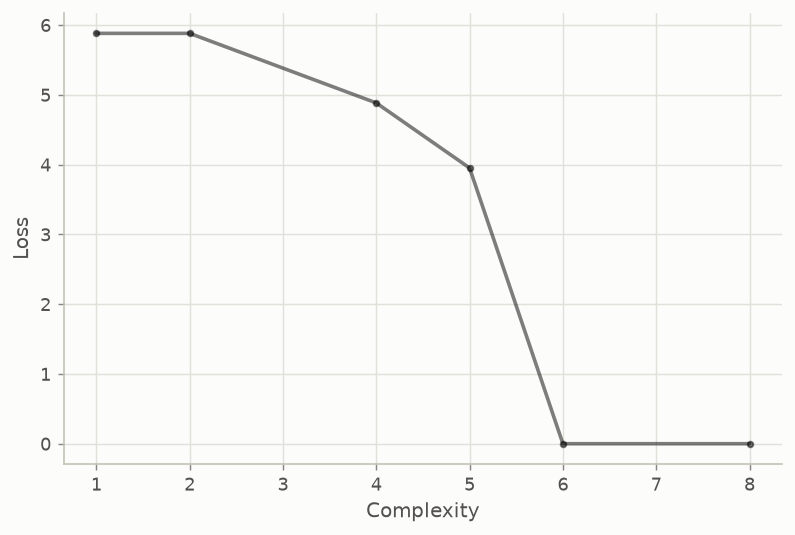

In [14]:
# Pareto front of solutions
plt.figure(figsize=(6, 4))
plt.scatter(f.complexity, f.loss, s=10, color="black", alpha=0.5)
plt.plot(f.complexity, f.loss, color="black", alpha=0.5)
plt.xlabel("Complexity")
plt.ylabel("Loss")
plt.show()

Note we actually found a solution that is not a state of the harmonic oscillator:

$$\psi = e^{-x^2/2}, \qquad E = \tfrac12,$$

It is a real solution of the differential equation and it is not
a state of the harmonic oscillator, because it grows in both directions and cannot be normalised.
There is no energy $-\tfrac12$ in this well and no measurement would ever return one.

That is $\psi_0 = e^{-x^2/2}$ and $E_0 = \tfrac12$, from a grid of $x$ values and a potential and
nothing else.

The overall scale of the recovered $\psi$ comes back small, because the anchor is the one term in
the residual that is not invariant under $\psi \to c\psi$ and the search can cheapen it by
shrinking the amplitude. That costs us nothing, since normalisation was never determined here
anyway, and it is why the figure above compares shapes with both curves scaled to peak at one.

A useful check is to take the recovered $\psi$, differentiate it numerically with no reference to
what the search was optimising, and ask whether its local energy is actually flat.

## Choosing which state you get

Here is where templates stop being a convenience and start doing the physics.

The residual is satisfied by *every* eigenstate, so nothing so far says which one we get. What
separates them is nodes: $\psi_n$ crosses zero $n$ times, and that is the only thing that
distinguishes the ground state from the rest. So we write the node structure into the template and
leave everything else free,

$$\psi(x) = N(x)\, f(x)$$

with $N$ known and $f$ nodeless. For the first excited state $N = x$, and by the product rule
$\psi'' = 2f' + x f''$, which we write out directly in the combine string. 
Then, we can divide the residual by $f$ and the we dont have the spurious singularity.

E = 1.499973    exact 1.5


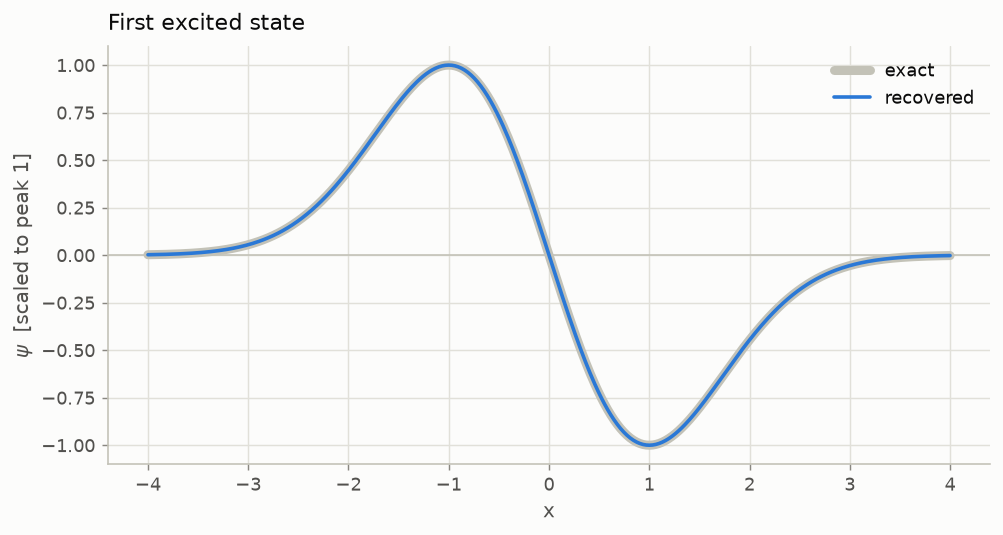

In [15]:
# psi = x f  ->  psi'' = 2 f' + x f''
N1 = ("d1 = D(f, 1); d2 = D(d1, 1); fx = f(x); "
      "(-d1(x) - 0.5f0*x*d2(x) + (V - E[1])*x*fx) / fx + w*fx*fx")

first = solve_1d(N1, {"E": 1})
front1 = classify_front_1d(first, node_factor=lambda x: x)
row1 = physical_rows(front1).iloc[0]
psi1, E1 = wavefunction(row1.equation, node_factor=lambda x: x), row1.E
print(f"E = {E1:.6f}    exact {harmonic_energy(1)}")
s3.plot_candidate(psi1, harmonic_exact(1), title="First excited state")

Same equation, same collocation points, same operators, and a different physical state comes out,
chosen entirely by the shape we asked for. That is about as direct a demonstration of a structural
prior changing the answer as this tutorial has.

Two nodes next. Now $N(x) = x^2 + c$, and we do not know where the nodes sit, so $c$ becomes a
second fitted parameter alongside $E$ and the search has to place them itself.

In [16]:
# psi = (x^2 + c) f  ->  psi'' = 2 f + 4 x f' + (x^2 + c) f''
N2 = ("d1 = D(f, 1); d2 = D(d1, 1); fx = f(x); N = x*x + c[1]; "
      "(-0.5f0*(2.0f0*fx + 4.0f0*x*d1(x) + N*d2(x)) + (V - E[1])*N*fx) / fx "
      "+ w*fx*fx")

second = solve_1d(N2, {"E": 1, "c": 1}, maxsize=16)
second.equations_[["complexity", "loss", "equation"]]

,complexity,loss,equation
0,1,101.482290,f = 0.00012810058; E = [1.0401361]; c = [-11.8...
1,5,100.472690,f = (#1 - 0.028681127) * 0.0019575031; E = [5....
2,6,0.000058,f = exp(#1 * (#1 * -0.49992344)); E = [2.50022...
3,8,0.000005,f = exp((#1 * #1) * -0.49995014) * 0.24440202;...
4,12,0.000004,f = exp(#1 - (((#1 * #1) * 0.5000148) + #1)) *...


E = 2.500835   exact 2.5
c = -0.50003   exact -0.5, so nodes at x = +-0.7071


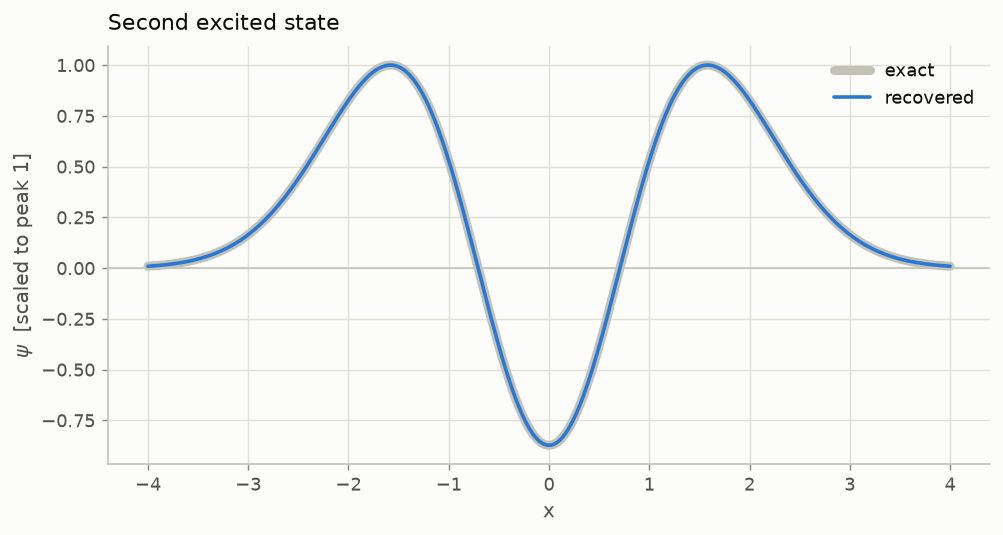

In [17]:
front2 = second.equations_.reset_index(drop=True)
row2 = front2[front2.loss <= front2.loss.min() * 1.5].sort_values("complexity").iloc[0]
c2, E2 = parameter(row2.equation, "c"), energy(row2.equation)
psi2 = wavefunction(row2.equation, node_factor=lambda x: x ** 2 + c2)
print(f"E = {E2:.6f}   exact {harmonic_energy(2)}")
print(f"c = {c2:.5f}   exact -0.5, so nodes at x = +-{abs(c2) ** 0.5:.4f}")
s3.plot_candidate(psi2, harmonic_exact(2), title="Second excited state")


---

# Part II. Hydrogen, and a coincidence that isn't one

Now the real atom. Same idea, one equation and a grid of points where we insist it holds,

$$-\tfrac12 \nabla^2 \psi - \frac{\psi}{r} = E\,\psi$$

in atomic units, where the potential is the pull of the proton. The interesting part is not that
it works. It is what the answers turn out to have in common, which is something nobody would
predict from the equation by looking at it, and which stopped being a coincidence only when Pauli
explained it.

## The prior that turns a 3D problem into a 1D one

A search over functions of three variables would be hopeless, and we do not have to run one,
because we already know how the angles work. Every solution of a central-force problem factors
into a radial part and a spherical harmonic,

$$\psi(r, \theta, \phi) = R(r)\, Y_{\ell m}(\theta, \phi),$$

and this is the thing we are handing over. It is exactly the move from this morning, a structural
prior written into a template, and here it does something dramatic. Put that form into the
Laplacian and the angular dependence cancels out of the equation completely, leaving one ordinary
differential equation in $r$ alone,

$$-\tfrac12\left[R'' + \frac{2}{r}R' - \frac{\ell(\ell+1)}{r^2}R\right] - \frac{R}{r} = E\,R.$$

The spherical harmonic never appears again. All that survives of it is the integer $\ell$ in that
centrifugal term, so the search has to find a function of one variable and one number, which is
the situation we were in all through Part I.

We can check the cancellation is real rather than take it on faith. Below is the local energy of
an exact solution evaluated along different polar angles, which should not depend on $\theta$ at
all if the factorisation did what we claimed.

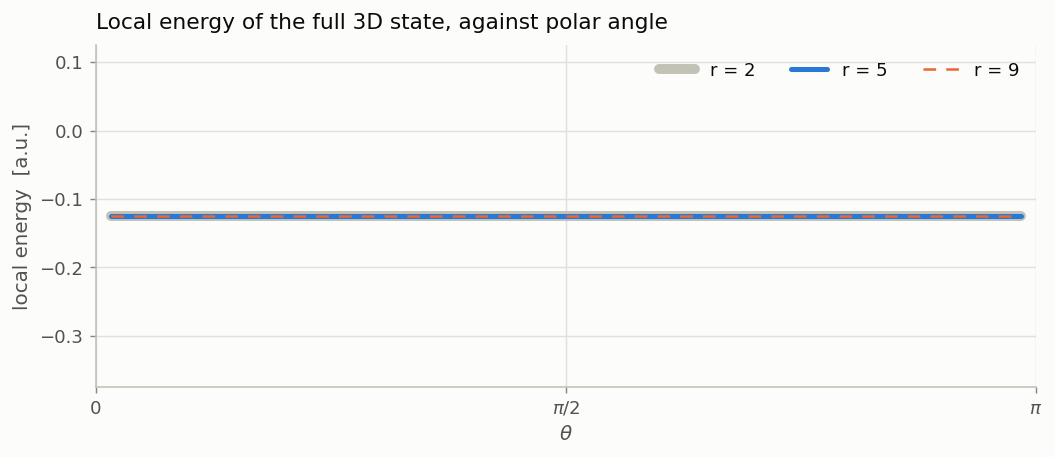

In [21]:
s3.plot_angular_check(exact_radial(2, 1), l=1)

Three radii, three flat lines, and they lie on top of each other at the same value, none of them
bending as $\theta$ sweeps from pole to pole. The angles really are gone.

## 10. The machinery, again

Almost identical to Part I. `D(R, 1)` differentiates the component, composing twice gives $R''$,
and the residual is the template's own output, minimised against a column of zeros. Dividing by
$R$ makes the trivial $R = 0$ non-finite so the search cannot take it, and makes the
differential-equation part invariant under $R \to cR$. The decay anchor `w*R*R` is doing the job it
did in section 6, and it is still the one term that is not invariant, which is the price of asking
for a normalisable solution at all.

The potential travels as an ordinary column, which will matter a great deal in section 14.

In [22]:
NODELESS = ("d1 = D(R, 1); d2 = D(d1, 1); Rr = R(r); "
            "kin = -0.5f0*(d2(r) + (2.0f0/r)*d1(r) - L*Rr/(r*r)); "
            "(kin + V*Rr)/Rr - E[1] + w*Rr*Rr")

# For a state with one radial node, write R = (r + c) f(r) and divide by f rather
# than by R, so the residual stays finite where R legitimately vanishes. E has to
# multiply the whole of R inside the numerator, not sit outside the division.
ONE_NODE = ("d1 = D(R, 1); d2 = D(d1, 1); f = R(r); N = r + c[1]; "
            "Rr = N*f; dR = f + N*d1(r); ddR = 2.0f0*d1(r) + N*d2(r); "
            "kin = -0.5f0*(ddR + (2.0f0/r)*dR - L*Rr/(r*r)); "
            "(kin + V*Rr - E[1]*Rr)/f + w*f*f")

SEARCH = dict(binary_operators=["+", "-", "*"], unary_operators=["exp"],
              elementwise_loss="(p, t) -> p^2", niterations=30, maxsize=14, **REPRO)

def solve_radial(combine, parameters, X, y, seed=0, **kw):
    spec = TemplateExpressionSpec(expressions=["R"], variable_names=COLS,
                                  parameters=parameters, combine=combine)
    t = time.time()
    m = PySRRegressor(expression_spec=spec, random_state=seed, **{**SEARCH, **kw})
    m.fit(X, y, variable_names=COLS)
    print(f"{time.time() - t:.0f}s")
    return m

## 11. The ground state

Start with $\ell = 0$, no angular momentum, and ask for the simplest thing that satisfies the
equation and decays.

In [23]:
Xh, yh = radial_grid(l=0, potential=coulomb, lo=0.4, hi=14.0)
h1s = solve_radial(NODELESS, {"E": 1}, Xh, yh)
front1s = classify_front(h1s)
row = s3.simplest_within(front1s[front1s.bound])
R_1s = radial_function(row.equation)
print(f"{row.equation}\nE = {row.E:.6f}      exact {exact_energy(1)}")

21s
R = exp(-0.57103765 - #1); E = [-0.5]
E = -0.500000      exact -0.5


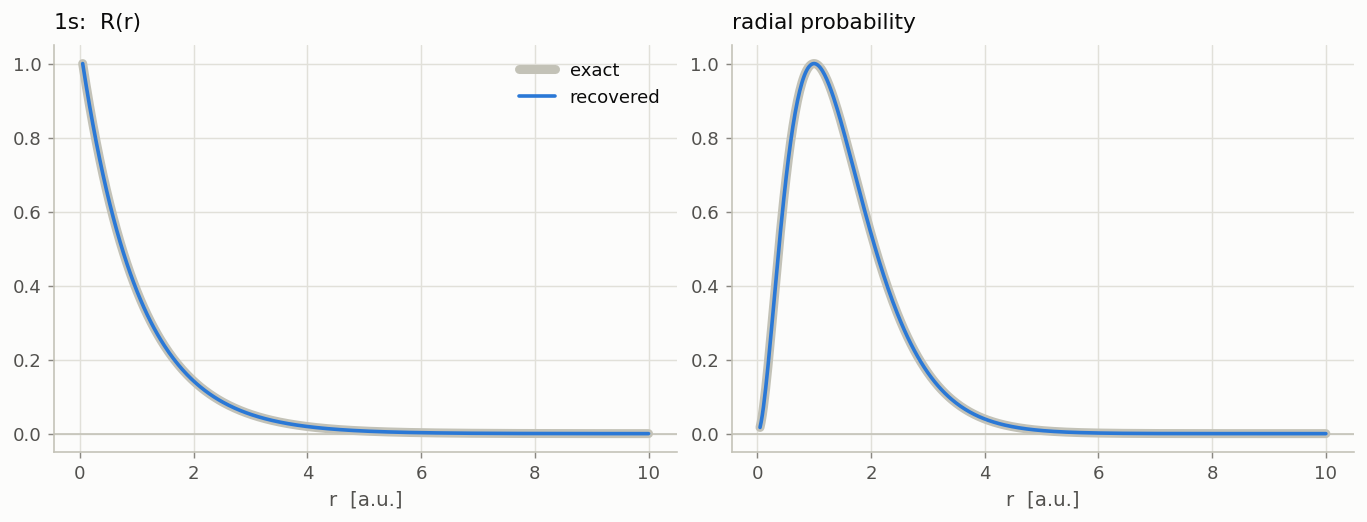

In [24]:
s3.plot_radial(R_1s, n=1, l=0, hi=10.0)

That is $R = e^{-r}$ up to the normalisation the equation never fixed, and $E = -\tfrac12$
hartree, which is $-13.6$ eV, so it costs $13.6$ eV to pull the electron off. That number came out
of a grid of radii and nothing else.

## 12. Give it angular momentum

Now $\ell = 1$. The only change is the integer in the centrifugal term, and the lowest state that
can live there is the 2p.

In [25]:
Xh, yh = radial_grid(l=1, potential=coulomb, lo=0.4, hi=24.0)
h2p = solve_radial(NODELESS, {"E": 1}, Xh, yh)
row2p = best_bound(classify_front(h2p))
R_2p = radial_function(row2p.equation)
print(f"{row2p.equation}\nE = {row2p.E:.6f}      exact {exact_energy(2)}")

14s
R = exp(-0.49999976 * #1) * #1; E = [-0.124999896]
E = -0.125000      exact -0.125


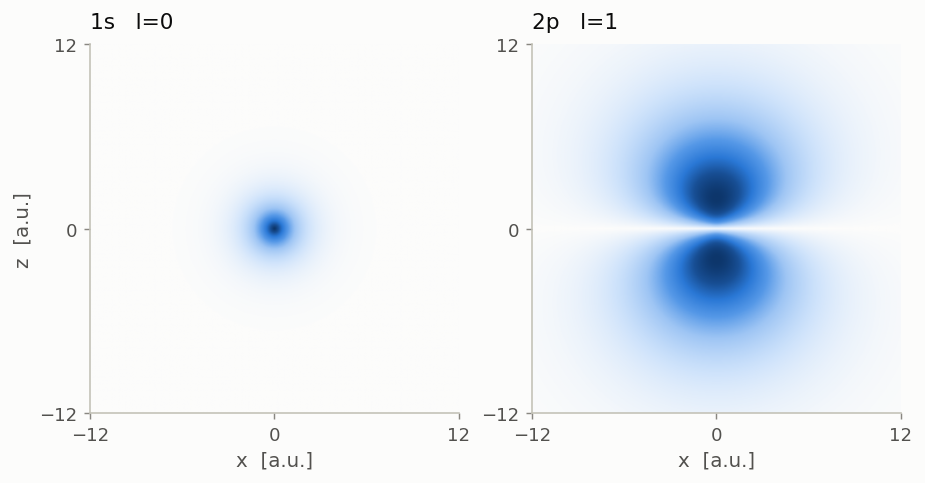

In [26]:
s3.plot_orbitals([("1s   l=0", R_1s, 0, 0), ("2p   l=1", R_2p, 1, 0)])

$R = r\,e^{-r/2}$, and the picture is the dumbbell every chemistry course draws, with its nodal
plane through the nucleus. Both panels are drawn on the same spatial axes, so the 2p being visibly
larger than the 1s is a real statement about the atom and not a choice of framing. The shading in
each panel is normalised to its own peak, since what we are reading off is shape.


Unil where can we take this?